# PersonaMem Multimodal Analysis (Stage 1 + Stage 2)

This notebook consolidates analysis for both benchmark stages in one place and extends the old plots with multimodal-aware logic.

What it covers:
- Stage 1 (memory fill): throughput, latency, token use, image ingestion diagnostics.
- Stage 2 (QA): retrieval/generation timing, modality slices, retrieval quality proxy stats.
- Cross-stage joins at user level (how ingestion profile relates to QA behavior).
- Optional LLM-as-a-judge accuracy analysis (if a checked results file is provided/found).

In [15]:
from pathlib import Path
import json
import ast
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from IPython.display import display

sns.set_theme(style="whitegrid", context="talk", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linestyle": "--",
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def pct(x):
    return f"{100*x:.1f}%"


def wilson_ci(k, n, z=1.96):
    if n <= 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * math.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0.0, center - half), min(1.0, center + half)


def add_rate_ci(df, success_col="success", total_col="total"):
    lows, highs = [], []
    for k, n in zip(df[success_col], df[total_col]):
        lo, hi = wilson_ci(k, n)
        lows.append(lo)
        highs.append(hi)
    out = df.copy()
    out["ci_low"] = lows
    out["ci_high"] = highs
    return out


def _try_parse_query(raw):
    if isinstance(raw, dict):
        return raw
    if not isinstance(raw, str):
        return {}
    text = raw.strip()
    if not text:
        return {}
    try:
        return json.loads(text)
    except Exception:
        pass
    try:
        return ast.literal_eval(text)
    except Exception:
        return {}


def infer_has_image_from_query(user_query):
    q = _try_parse_query(user_query)
    content = q.get("content")
    if isinstance(content, list):
        for part in content:
            if isinstance(part, dict) and part.get("type") in {"image", "image_url", "input_image"}:
                return True
    return False

In [16]:
# ---- Configuration ----
# Set this to your latest experiment folder.
EXPERIMENT_DIR = Path("benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2")
assert EXPERIMENT_DIR.is_dir(), f"Missing experiment dir: {EXPERIMENT_DIR}"

# Optional: explicit checked-results path from LLM-as-a-judge.
# If None, notebook tries to auto-detect a file in the experiment dir.
CHECKED_RESULTS_PATH = None


def newest_file(pattern):
    files = sorted(EXPERIMENT_DIR.glob(pattern), key=lambda p: p.stat().st_mtime)
    return files[-1] if files else None

stage1_path = newest_file("stage1*_fill_*.json")
stage2_path = newest_file("stage2*_qa_*.json")

# Avoid *_answers.json for main stage2 log.
if stage2_path and stage2_path.name.endswith("_answers.json"):
    stage2_candidates = [
        p for p in EXPERIMENT_DIR.glob("stage2*_qa_*.json")
        if not p.name.endswith("_answers.json")
    ]
    stage2_path = sorted(stage2_candidates, key=lambda p: p.stat().st_mtime)[-1] if stage2_candidates else None

if CHECKED_RESULTS_PATH is None:
    checked_candidates = sorted(EXPERIMENT_DIR.glob("*checked*.json"), key=lambda p: p.stat().st_mtime)
    CHECKED_RESULTS_PATH = checked_candidates[-1] if checked_candidates else None

assert stage1_path is not None, "No stage1 fill log found in experiment directory"
assert stage2_path is not None, "No stage2 qa log found in experiment directory"

print("Using:")
print("- Stage 1:", stage1_path)
print("- Stage 2:", stage2_path)
print("- Checked results:", CHECKED_RESULTS_PATH if CHECKED_RESULTS_PATH else "not found (optional)")

Using:
- Stage 1: benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/stage1_RUN-1_fill_20260311_184105.json
- Stage 2: benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/stage2_RUN-3_qa_20260312_112818.json
- Checked results: benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/checked_results.json


In [17]:
# ---- Load logs ----
with open(stage1_path, "r") as f:
    stage1_log = json.load(f)

with open(stage2_path, "r") as f:
    stage2_log = json.load(f)

s1 = pd.DataFrame(stage1_log.get("per_user", []))
s2 = pd.DataFrame(stage2_log.get("per_qa", []))

assert not s1.empty, "Stage 1 per_user is empty"
assert not s2.empty, "Stage 2 per_qa is empty"

# Stage 1 multimodal flags
s1["images_processed"] = pd.to_numeric(s1.get("images_processed", 0), errors="coerce").fillna(0).astype(int)
s1["is_multimodal_user"] = s1["images_processed"] > 0
s1["modality_user"] = np.where(s1["is_multimodal_user"], "Multimodal users", "Text-only users")
s1["input_tokens"] = pd.to_numeric(s1.get("input_tokens", np.nan), errors="coerce")
s1["wall_seconds"] = pd.to_numeric(s1.get("wall_seconds", np.nan), errors="coerce")

# Stage 2 multimodal flags
s2["user_images_processed"] = pd.to_numeric(s2.get("user_images_processed", 0), errors="coerce").fillna(0).astype(int)
query_has_image = s2.get("user_query", pd.Series([None] * len(s2))).apply(infer_has_image_from_query)
s2["has_image"] = (s2["user_images_processed"] > 0) | query_has_image
s2["modality"] = np.where(s2["has_image"], "Multimodal QA", "Text-only QA")

for col in ["wall_seconds", "search_calls", "num_results", "input_tokens", "answer_wall_seconds", "answer_input_tokens", "answer_llm_calls"]:
    if col in s2.columns:
        s2[col] = pd.to_numeric(s2[col], errors="coerce")

s2["success_bool"] = s2.get("success", False).fillna(False).astype(bool)
s2["has_answer_error"] = s2.get("answer_error", pd.Series([None] * len(s2))).notna()

print(f"Stage 1 users: {len(s1)}")
print(f"Stage 2 QA rows: {len(s2)}")
print(f"Stage 1 multimodal users: {s1['is_multimodal_user'].sum()} / {len(s1)} ({pct(s1['is_multimodal_user'].mean())})")
print(f"Stage 2 multimodal QA: {s2['has_image'].sum()} / {len(s2)} ({pct(s2['has_image'].mean())})")

Stage 1 users: 195
Stage 2 QA rows: 5000
Stage 1 multimodal users: 95 / 195 (48.7%)
Stage 2 multimodal QA: 2487 / 5000 (49.7%)


## Stage 1: Fill Memory Analysis

Focus:
- overall throughput and resource usage
- multimodal vs text-only user differences
- image ingestion modes and fallback diagnostics

In [18]:
# Stage 1 overview
s1_overview = pd.DataFrame([
    {
        "num_users": len(s1),
        "success_rate": s1["success"].fillna(False).mean() if "success" in s1 else np.nan,
        "total_wall_hours": s1["wall_seconds"].sum() / 3600,
        "median_wall_seconds": s1["wall_seconds"].median(),
        "total_input_tokens": s1["input_tokens"].sum(skipna=True),
        "median_input_tokens": s1["input_tokens"].median(skipna=True),
        "total_images_processed": s1["images_processed"].sum(),
        "multimodal_user_share": s1["is_multimodal_user"].mean(),
    }
])

mod_stats_s1 = (
    s1.groupby("modality_user", dropna=False)
      .agg(
          users=("user_id", "count"),
          success=("success", lambda x: np.sum(pd.Series(x).fillna(False))),
          wall_mean=("wall_seconds", "mean"),
          wall_median=("wall_seconds", "median"),
          input_tokens_median=("input_tokens", "median"),
          images_processed_total=("images_processed", "sum"),
      )
      .reset_index()
)
mod_stats_s1["success_rate"] = mod_stats_s1["success"] / mod_stats_s1["users"]

print("Stage 1 overview")
display(s1_overview)
print("\nStage 1 by user modality")
display(mod_stats_s1)

Stage 1 overview


,num_users,success_rate,total_wall_hours,median_wall_seconds,total_input_tokens,median_input_tokens,total_images_processed,multimodal_user_share
0,195,1.0,5.829215,97.852691,6161067,31894.0,183,0.487179



Stage 1 by user modality


,modality_user,users,success,wall_mean,wall_median,input_tokens_median,images_processed_total,success_rate
0,Multimodal users,95,95,105.448104,100.067410,32018.0,183,1.0
1,Text-only users,100,100,109.676039,97.799233,31837.5,0,1.0


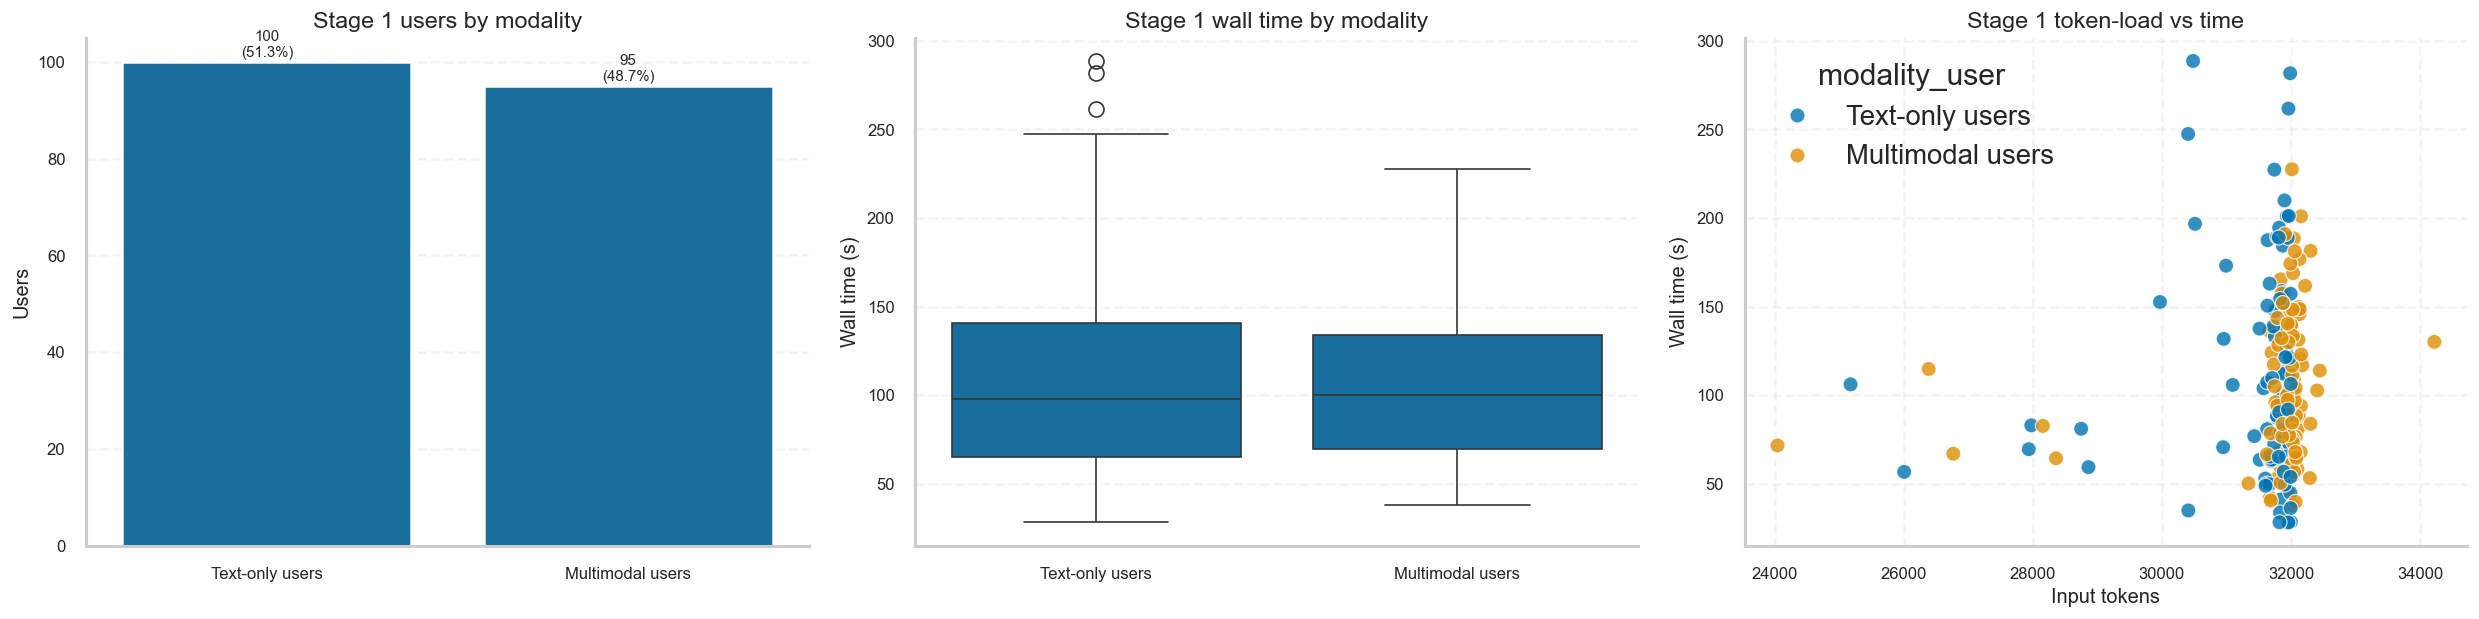

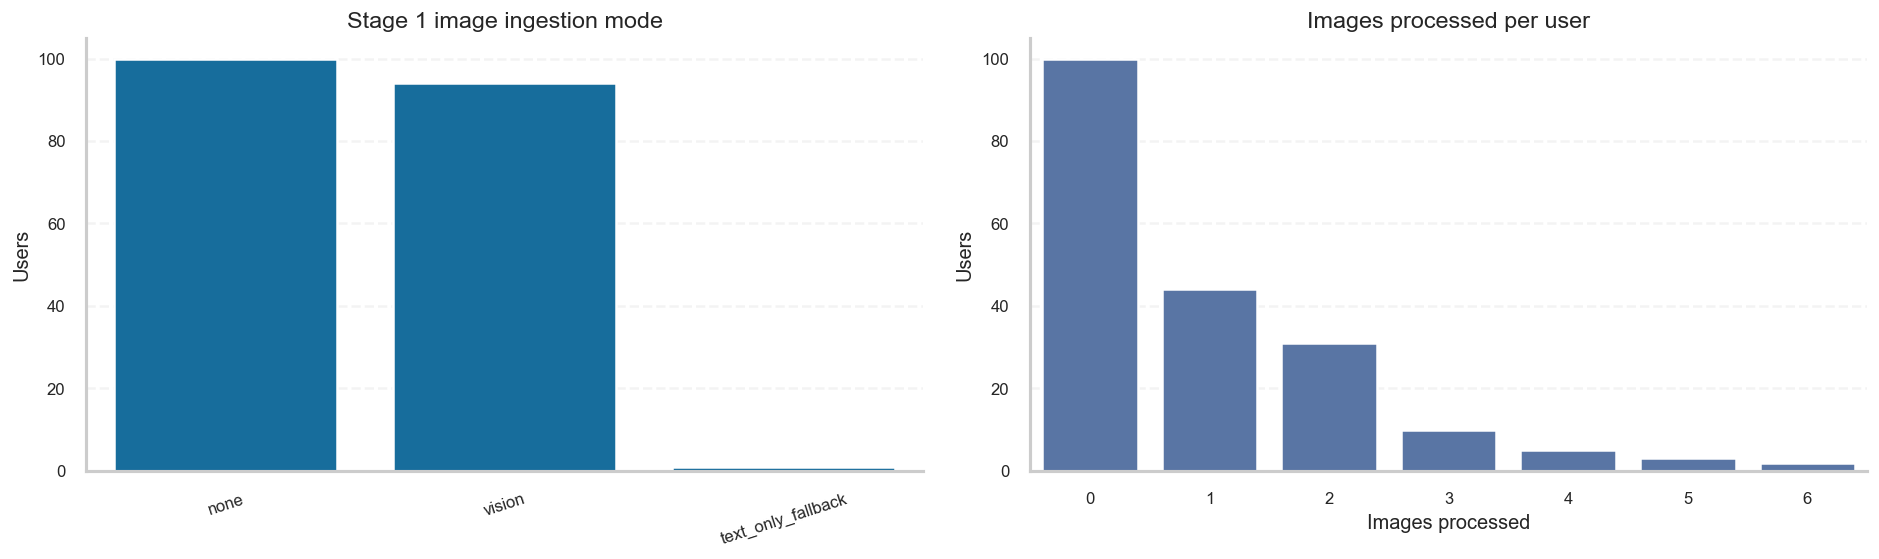

In [19]:
# Stage 1 plots
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# (1) User modality split
mod_counts = s1["modality_user"].value_counts().rename_axis("modality_user").reset_index(name="users")
sns.barplot(data=mod_counts, x="modality_user", y="users", ax=axes[0])
axes[0].set_title("Stage 1 users by modality")
axes[0].set_xlabel("")
axes[0].set_ylabel("Users")
for i, row in mod_counts.iterrows():
    axes[0].text(i, row["users"] + 0.5, f"{row['users']}\n({row['users']/len(s1):.1%})", ha="center", va="bottom", fontsize=9)

# (2) Wall-time distributions
sns.boxplot(data=s1, x="modality_user", y="wall_seconds", ax=axes[1])
axes[1].set_title("Stage 1 wall time by modality")
axes[1].set_xlabel("")
axes[1].set_ylabel("Wall time (s)")

# (3) Input tokens vs time
sns.scatterplot(
    data=s1,
    x="input_tokens",
    y="wall_seconds",
    hue="modality_user",
    alpha=0.8,
    ax=axes[2],
)
axes[2].set_title("Stage 1 token-load vs time")
axes[2].set_xlabel("Input tokens")
axes[2].set_ylabel("Wall time (s)")

plt.tight_layout()
plt.show()

# Additional ingestion diagnostics
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mode_counts = s1.get("image_ingest_mode", pd.Series(dtype=object)).fillna("unknown").value_counts().reset_index()
mode_counts.columns = ["image_ingest_mode", "users"]
sns.barplot(data=mode_counts, x="image_ingest_mode", y="users", ax=axes[0])
axes[0].set_title("Stage 1 image ingestion mode")
axes[0].set_xlabel("")
axes[0].set_ylabel("Users")
axes[0].tick_params(axis="x", rotation=18)

img_dist = s1["images_processed"].value_counts().sort_index().reset_index()
img_dist.columns = ["images_processed", "users"]
sns.barplot(data=img_dist, x="images_processed", y="users", ax=axes[1], color=sns.color_palette("deep")[0])
axes[1].set_title("Images processed per user")
axes[1].set_xlabel("Images processed")
axes[1].set_ylabel("Users")

plt.tight_layout()
plt.show()

## Stage 2: QA Analysis

Focus:
- multimodal QA split and confidence intervals
- retrieval behavior (`num_results`) by modality
- latency and token usage across retrieval + answer generation

In [20]:
# Stage 2 overview and modality-level stats
s2_overview = pd.DataFrame([
    {
        "num_qa": len(s2),
        "qa_success_rate": s2["success_bool"].mean(),
        "multimodal_qa_share": s2["has_image"].mean(),
        "total_wall_hours": s2["wall_seconds"].sum(skipna=True) / 3600,
        "median_wall_seconds": s2["wall_seconds"].median(skipna=True),
        "total_answer_wall_hours": s2["answer_wall_seconds"].sum(skipna=True) / 3600,
        "median_answer_wall_seconds": s2["answer_wall_seconds"].median(skipna=True),
        "zero_retrieval_share": (s2["num_results"].fillna(0) == 0).mean(),
        "answer_error_rate": s2["has_answer_error"].mean(),
    }
])

mod_stats_s2 = (
    s2.groupby("modality", dropna=False)
      .agg(
          total=("question_id", "count"),
          success=("success_bool", "sum"),
          avg_num_results=("num_results", "mean"),
          median_num_results=("num_results", "median"),
          avg_search_wall=("wall_seconds", "mean"),
          median_search_wall=("wall_seconds", "median"),
          avg_answer_wall=("answer_wall_seconds", "mean"),
          median_answer_wall=("answer_wall_seconds", "median"),
          avg_input_tokens=("input_tokens", "mean"),
          avg_answer_input_tokens=("answer_input_tokens", "mean"),
      )
      .reset_index()
)
mod_stats_s2["success_rate"] = mod_stats_s2["success"] / mod_stats_s2["total"]
mod_stats_s2 = add_rate_ci(mod_stats_s2, success_col="success", total_col="total")

print("Stage 2 overview")
display(s2_overview)
print("\nStage 2 by QA modality")
display(mod_stats_s2[[
    "modality", "total", "success_rate", "ci_low", "ci_high",
    "avg_num_results", "median_num_results", "avg_search_wall", "avg_answer_wall"
]])

Stage 2 overview


,num_qa,qa_success_rate,multimodal_qa_share,total_wall_hours,median_wall_seconds,total_answer_wall_hours,median_answer_wall_seconds,zero_retrieval_share,answer_error_rate
0,5000,0.9984,0.4974,7.212562,2.421021,4.142131,2.633573,0.1718,0.0



Stage 2 by QA modality


,modality,total,success_rate,ci_low,ci_high,avg_num_results,median_num_results,avg_search_wall,avg_answer_wall
0,Multimodal QA,2487,0.998794,0.996459,0.99959,7.631685,10.0,4.652040,2.894341
1,Text-only QA,2513,0.998010,0.995351,0.99915,8.851572,10.0,5.728452,3.078999


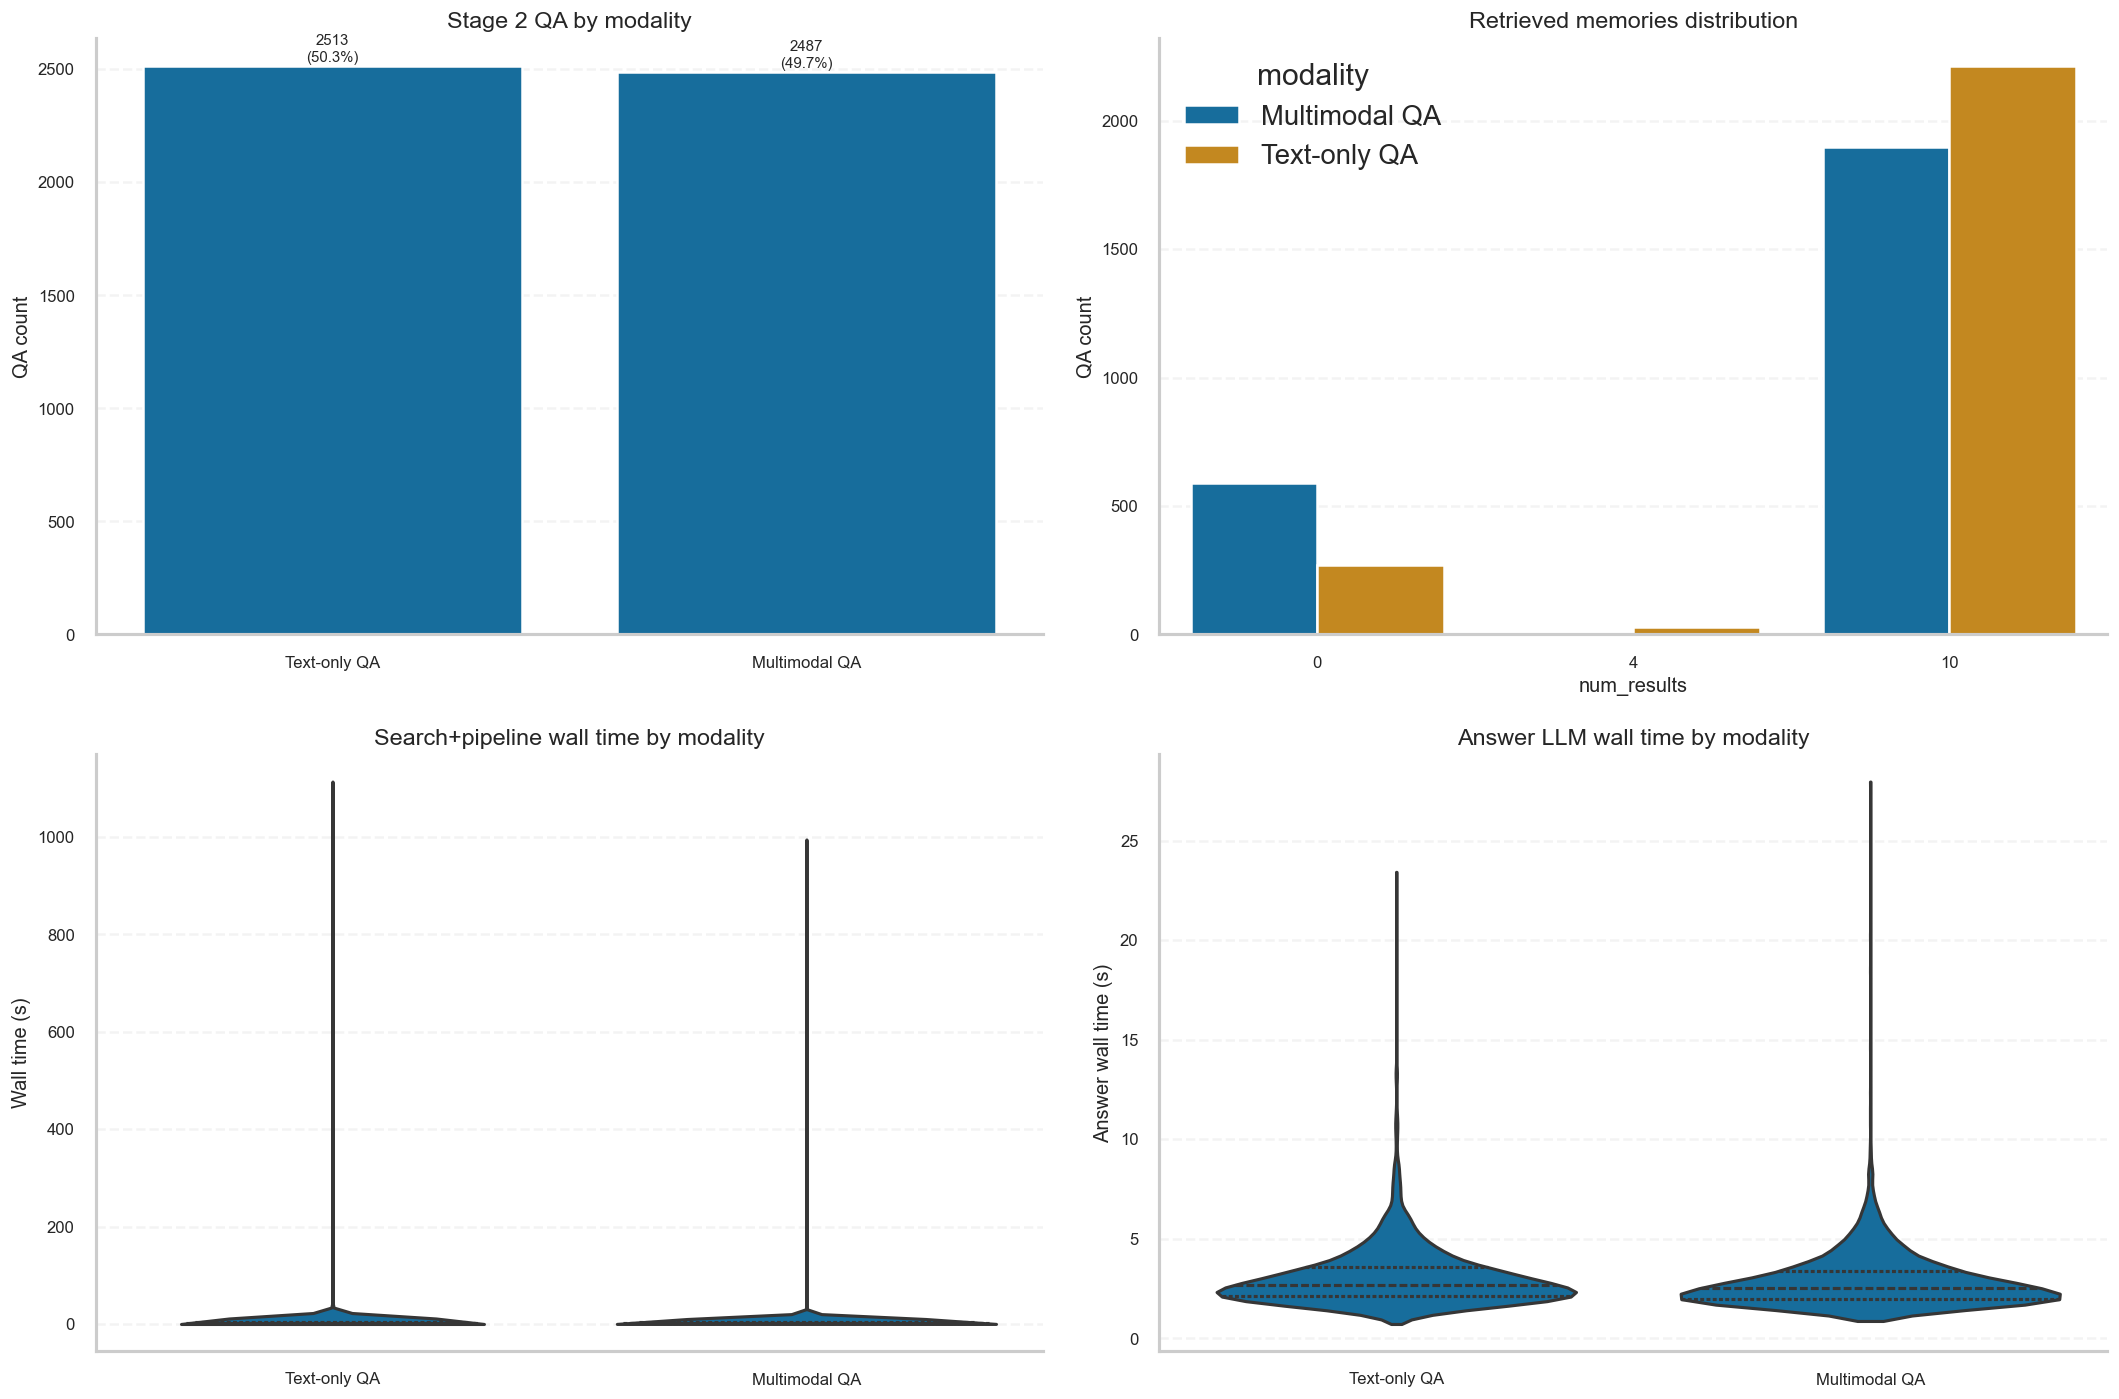

In [21]:
# Stage 2 plots: modality split, retrieval profile, time profile
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# (1) QA count by modality
qa_counts = s2["modality"].value_counts().rename_axis("modality").reset_index(name="qa_count")
sns.barplot(data=qa_counts, x="modality", y="qa_count", ax=axes[0, 0])
axes[0, 0].set_title("Stage 2 QA by modality")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("QA count")
for i, row in qa_counts.iterrows():
    axes[0, 0].text(i, row["qa_count"] + 8, f"{row['qa_count']}\n({row['qa_count']/len(s2):.1%})", ha="center", va="bottom", fontsize=9)

# (2) Retrieval count distribution
retrieval_dist = (
    s2.groupby(["modality", "num_results"], dropna=False)
      .size()
      .reset_index(name="count")
)
sns.barplot(data=retrieval_dist, x="num_results", y="count", hue="modality", ax=axes[0, 1])
axes[0, 1].set_title("Retrieved memories distribution")
axes[0, 1].set_xlabel("num_results")
axes[0, 1].set_ylabel("QA count")

# (3) Search wall time by modality
sns.violinplot(data=s2, x="modality", y="wall_seconds", cut=0, inner="quart", ax=axes[1, 0])
axes[1, 0].set_title("Search+pipeline wall time by modality")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Wall time (s)")

# (4) Answer LLM wall time by modality
sns.violinplot(data=s2.dropna(subset=["answer_wall_seconds"]), x="modality", y="answer_wall_seconds", cut=0, inner="quart", ax=axes[1, 1])
axes[1, 1].set_title("Answer LLM wall time by modality")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Answer wall time (s)")

plt.tight_layout()
plt.show()

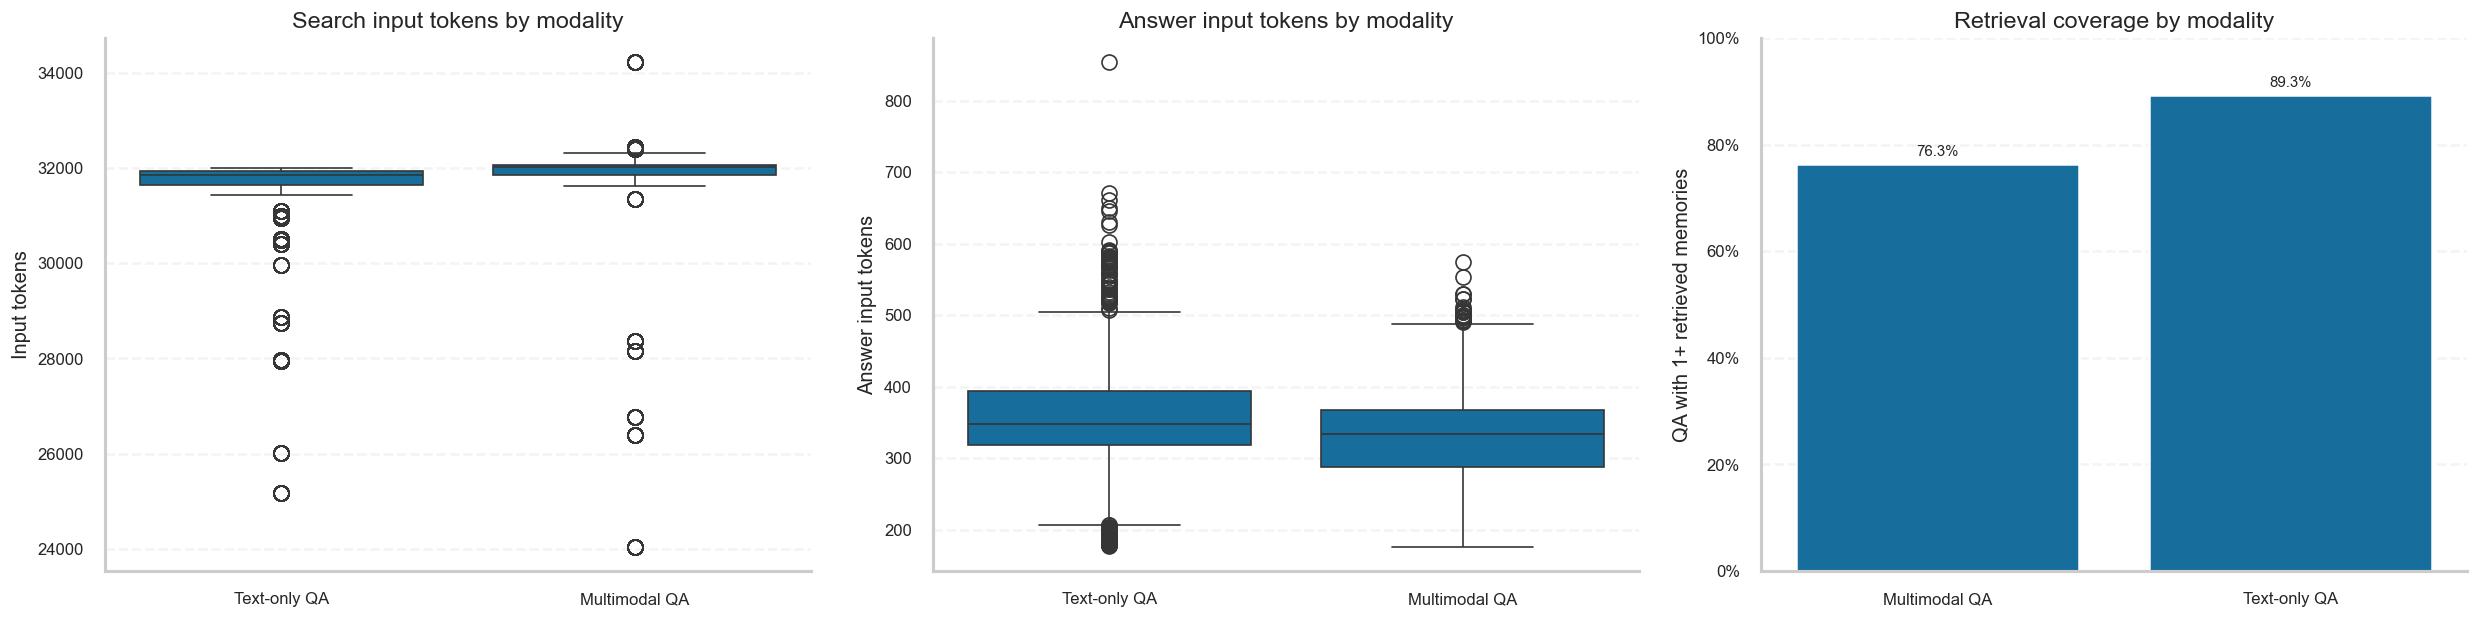

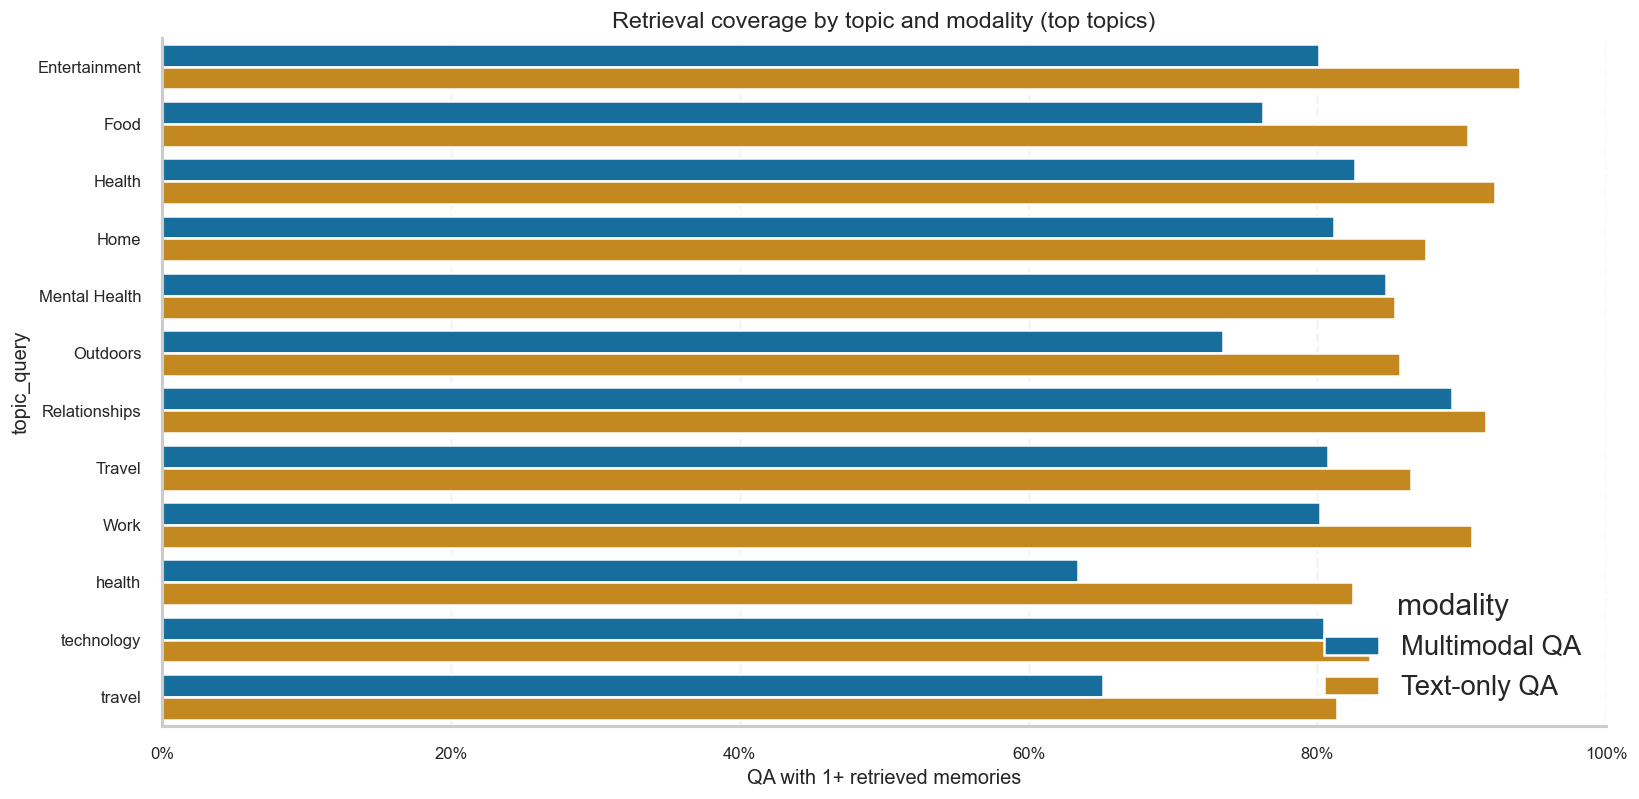

In [22]:
# Stage 2 deeper cuts: tokens, retrieval success proxy, and topic slices
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

# (1) Input token distribution
sns.boxplot(data=s2, x="modality", y="input_tokens", ax=axes[0])
axes[0].set_title("Search input tokens by modality")
axes[0].set_xlabel("")
axes[0].set_ylabel("Input tokens")

# (2) Answer input token distribution
sns.boxplot(data=s2.dropna(subset=["answer_input_tokens"]), x="modality", y="answer_input_tokens", ax=axes[1])
axes[1].set_title("Answer input tokens by modality")
axes[1].set_xlabel("")
axes[1].set_ylabel("Answer input tokens")

# (3) Retrieval coverage proxy (num_results > 0)
retr_cov = (
    s2.assign(retrieved_any=(s2["num_results"].fillna(0) > 0))
      .groupby("modality", dropna=False)["retrieved_any"]
      .mean()
      .reset_index(name="retrieval_coverage")
)
sns.barplot(data=retr_cov, x="modality", y="retrieval_coverage", ax=axes[2])
axes[2].set_ylim(0, 1)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_title("Retrieval coverage by modality")
axes[2].set_xlabel("")
axes[2].set_ylabel("QA with 1+ retrieved memories")

for i, row in retr_cov.iterrows():
    axes[2].text(i, row["retrieval_coverage"] + 0.01, f"{row['retrieval_coverage']:.1%}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Topic-level slice (top topics only)
if "topic_query" in s2.columns:
    top_topics = s2["topic_query"].fillna("Unknown").value_counts().head(12).index
    topic_df = s2[s2["topic_query"].fillna("Unknown").isin(top_topics)].copy()
    topic_perf = (
        topic_df.assign(retrieved_any=(topic_df["num_results"].fillna(0) > 0))
               .groupby(["topic_query", "modality"], dropna=False)
               .agg(total=("question_id", "count"), retrieval_coverage=("retrieved_any", "mean"))
               .reset_index()
    )

    plt.figure(figsize=(14, 7))
    sns.barplot(data=topic_perf, y="topic_query", x="retrieval_coverage", hue="modality")
    plt.xlim(0, 1)
    plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.title("Retrieval coverage by topic and modality (top topics)")
    plt.xlabel("QA with 1+ retrieved memories")
    plt.ylabel("topic_query")
    plt.tight_layout()
    plt.show()

## Cross-Stage User-Level Analysis

This section joins Stage 1 per-user logs with Stage 2 QA aggregates by `user_id` to see whether image-heavy ingestion users have different QA behavior.

Joined user-level rows: 195


,user_id,images_processed,modality_user,wall_seconds,input_tokens,qa_count,qa_multimodal_share,avg_num_results,avg_stage2_wall
0,10,0,Text-only users,63.568619,31516,31,0.0,4.0,2.398849
1,23,2,Multimodal users,149.743058,32118,30,1.0,10.0,2.587959
2,25,3,Multimodal users,227.454013,32014,26,1.0,10.0,2.221177
3,30,2,Multimodal users,200.930139,32158,26,1.0,10.0,1.814649
4,39,0,Text-only users,53.044815,31872,34,0.0,10.0,2.124066
5,44,5,Multimodal users,147.506818,31980,18,1.0,0.0,1.841354
6,54,1,Multimodal users,188.438741,32045,26,1.0,10.0,2.652666
7,55,0,Text-only users,261.677080,31961,41,0.0,10.0,2.541070
8,59,0,Text-only users,187.448157,31638,29,0.0,10.0,3.184148
9,60,0,Text-only users,54.356962,31945,30,0.0,10.0,2.270311


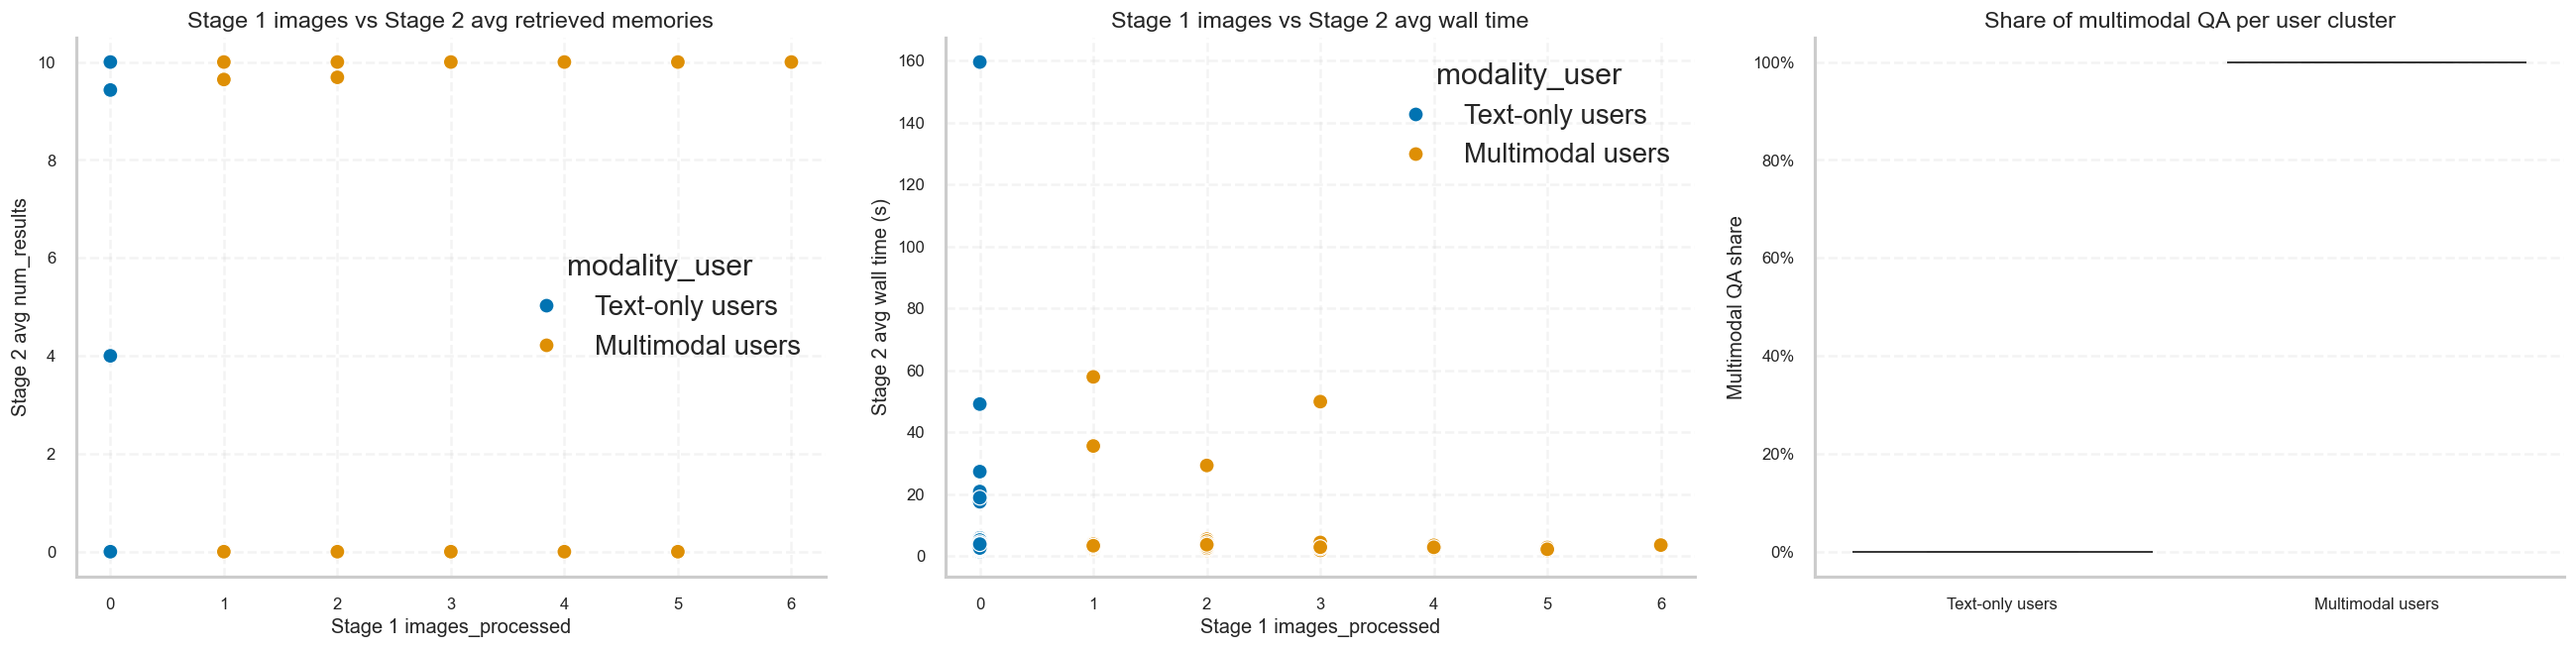

In [23]:
s2_user = (
    s2.groupby("user_id", dropna=False)
      .agg(
          qa_count=("question_id", "count"),
          qa_success_rate=("success_bool", "mean"),
          qa_multimodal_share=("has_image", "mean"),
          avg_num_results=("num_results", "mean"),
          avg_stage2_wall=("wall_seconds", "mean"),
          avg_answer_wall=("answer_wall_seconds", "mean"),
          avg_stage2_input_tokens=("input_tokens", "mean"),
      )
      .reset_index()
)

joined = s1.merge(s2_user, on="user_id", how="left")

print("Joined user-level rows:", len(joined))
display(joined[[
    "user_id", "images_processed", "modality_user", "wall_seconds", "input_tokens",
    "qa_count", "qa_multimodal_share", "avg_num_results", "avg_stage2_wall"
]].head(10))

fig, axes = plt.subplots(1, 3, figsize=(22, 5.8))

sns.scatterplot(
    data=joined,
    x="images_processed",
    y="avg_num_results",
    hue="modality_user",
    ax=axes[0],
)
axes[0].set_title("Stage 1 images vs Stage 2 avg retrieved memories")
axes[0].set_xlabel("Stage 1 images_processed")
axes[0].set_ylabel("Stage 2 avg num_results")

sns.scatterplot(
    data=joined,
    x="images_processed",
    y="avg_stage2_wall",
    hue="modality_user",
    ax=axes[1],
)
axes[1].set_title("Stage 1 images vs Stage 2 avg wall time")
axes[1].set_xlabel("Stage 1 images_processed")
axes[1].set_ylabel("Stage 2 avg wall time (s)")

sns.boxplot(data=joined, x="modality_user", y="qa_multimodal_share", ax=axes[2])
axes[2].set_title("Share of multimodal QA per user cluster")
axes[2].set_xlabel("")
axes[2].set_ylabel("Multimodal QA share")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()
plt.show()

## Optional: LLM-as-a-Judge Accuracy (if labels exist)

If `checked_results.json` is available, this section computes and plots correctness by modality and by topic. It is safe to run even when labels are missing.

Loaded judged QA rows: 5000


,modality,total,correct,accuracy,ci_low,ci_high
0,Multimodal QA,2487,1297,0.521512,0.501861,0.541097
1,Text-only QA,2513,1389,0.552726,0.533220,0.572071


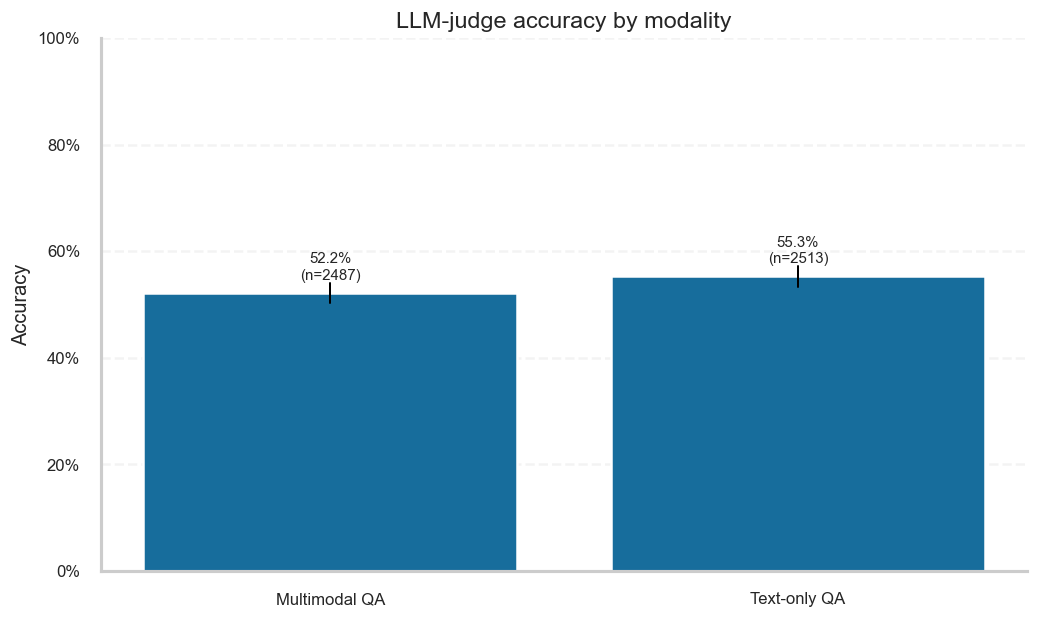

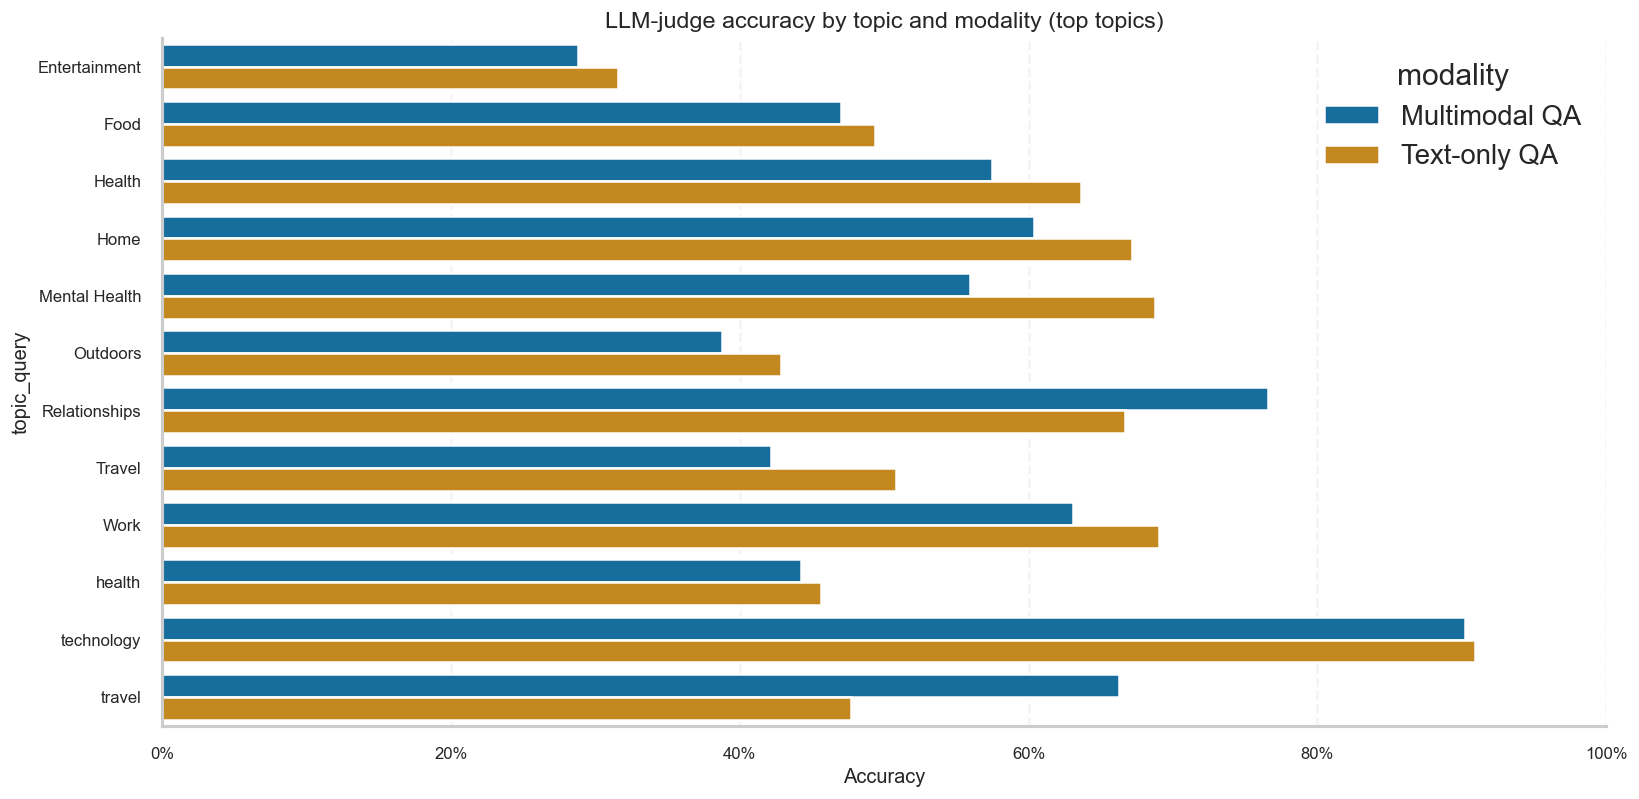

In [24]:
judge_df = None

if CHECKED_RESULTS_PATH and Path(CHECKED_RESULTS_PATH).is_file():
    with open(CHECKED_RESULTS_PATH, "r") as f:
        checked = json.load(f)

    checked = checked["per_qa"]

    # Common formats: list[dict] or dict with `results`.
    if isinstance(checked, dict):
        if "results" in checked and isinstance(checked["results"], list):
            judge_df = pd.DataFrame(checked["results"])
        else:
            judge_df = pd.DataFrame([checked])
    elif isinstance(checked, list):
        judge_df = pd.DataFrame(checked)

    if judge_df is not None and not judge_df.empty:
        # Normalize question_id for reliable join.
        if "question_id" not in judge_df.columns and {"user_id", "row_index"}.issubset(judge_df.columns):
            judge_df["question_id"] = judge_df["user_id"].astype(str) + ":" + judge_df["row_index"].astype(str)

        # Normalize correctness label.
        if "is_correct" in judge_df.columns:
            judge_df["is_correct_norm"] = judge_df["is_correct"].astype(str).str.upper().str.strip()
        elif "label" in judge_df.columns:
            judge_df["is_correct_norm"] = judge_df["label"].astype(str).str.upper().str.strip()
        else:
            judge_df["is_correct_norm"] = np.nan

        eval_df = s2.merge(judge_df[[c for c in ["question_id", "is_correct_norm"] if c in judge_df.columns]], on="question_id", how="inner")
        eval_df["correct"] = (eval_df["is_correct_norm"] == "CORRECT").astype(int)

        print(f"Loaded judged QA rows: {len(eval_df)}")

        # Accuracy by modality with Wilson CI
        acc_mod = (
            eval_df.groupby("modality", dropna=False)
                  .agg(total=("question_id", "count"), correct=("correct", "sum"))
                  .reset_index()
        )
        acc_mod["accuracy"] = acc_mod["correct"] / acc_mod["total"]
        acc_mod = add_rate_ci(acc_mod, success_col="correct", total_col="total")
        display(acc_mod)

        plt.figure(figsize=(9, 5.5))
        ax = sns.barplot(data=acc_mod, x="modality", y="accuracy")
        ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title("LLM-judge accuracy by modality")
        ax.set_xlabel("")
        ax.set_ylabel("Accuracy")

        # Add CI whiskers manually.
        for i, row in acc_mod.reset_index(drop=True).iterrows():
            y = row["accuracy"]
            lo, hi = row["ci_low"], row["ci_high"]
            ax.plot([i, i], [lo, hi], color="black", linewidth=1.2)
            ax.text(i, min(0.98, y + 0.02), f"{y:.1%}\n(n={int(row['total'])})", ha="center", va="bottom", fontsize=9)

        plt.tight_layout()
        plt.show()

        # Top topics accuracy by modality
        if "topic_query" in eval_df.columns:
            top_topics = eval_df["topic_query"].fillna("Unknown").value_counts().head(12).index
            ev_top = eval_df[eval_df["topic_query"].fillna("Unknown").isin(top_topics)].copy()
            acc_topic = (
                ev_top.groupby(["topic_query", "modality"], dropna=False)
                      .agg(total=("question_id", "count"), correct=("correct", "sum"))
                      .reset_index()
            )
            acc_topic["accuracy"] = acc_topic["correct"] / acc_topic["total"]

            plt.figure(figsize=(14, 7))
            sns.barplot(data=acc_topic, y="topic_query", x="accuracy", hue="modality")
            plt.xlim(0, 1)
            plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            plt.title("LLM-judge accuracy by topic and modality (top topics)")
            plt.xlabel("Accuracy")
            plt.ylabel("topic_query")
            plt.tight_layout()
            plt.show()
    else:
        print("Checked results file exists but could not be parsed into rows.")
else:
    print("No checked results detected. Skip this section or set CHECKED_RESULTS_PATH to your checked_results.json.")

In [25]:
# Optional exports for reports/slides
OUT_DIR = EXPERIMENT_DIR / "analysis_exports"
OUT_DIR.mkdir(parents=True, exist_ok=True)

mod_stats_s1.to_csv(OUT_DIR / "stage1_modality_stats.csv", index=False)
mod_stats_s2.to_csv(OUT_DIR / "stage2_modality_stats.csv", index=False)
joined.to_csv(OUT_DIR / "cross_stage_user_stats.csv", index=False)

print("Saved:")
print("-", OUT_DIR / "stage1_modality_stats.csv")
print("-", OUT_DIR / "stage2_modality_stats.csv")
print("-", OUT_DIR / "cross_stage_user_stats.csv")

Saved:
- benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/analysis_exports/stage1_modality_stats.csv
- benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/analysis_exports/stage2_modality_stats.csv
- benchmark_logs/multi_gpt-4.1.-mini_graph-img-preserved-2/analysis_exports/cross_stage_user_stats.csv


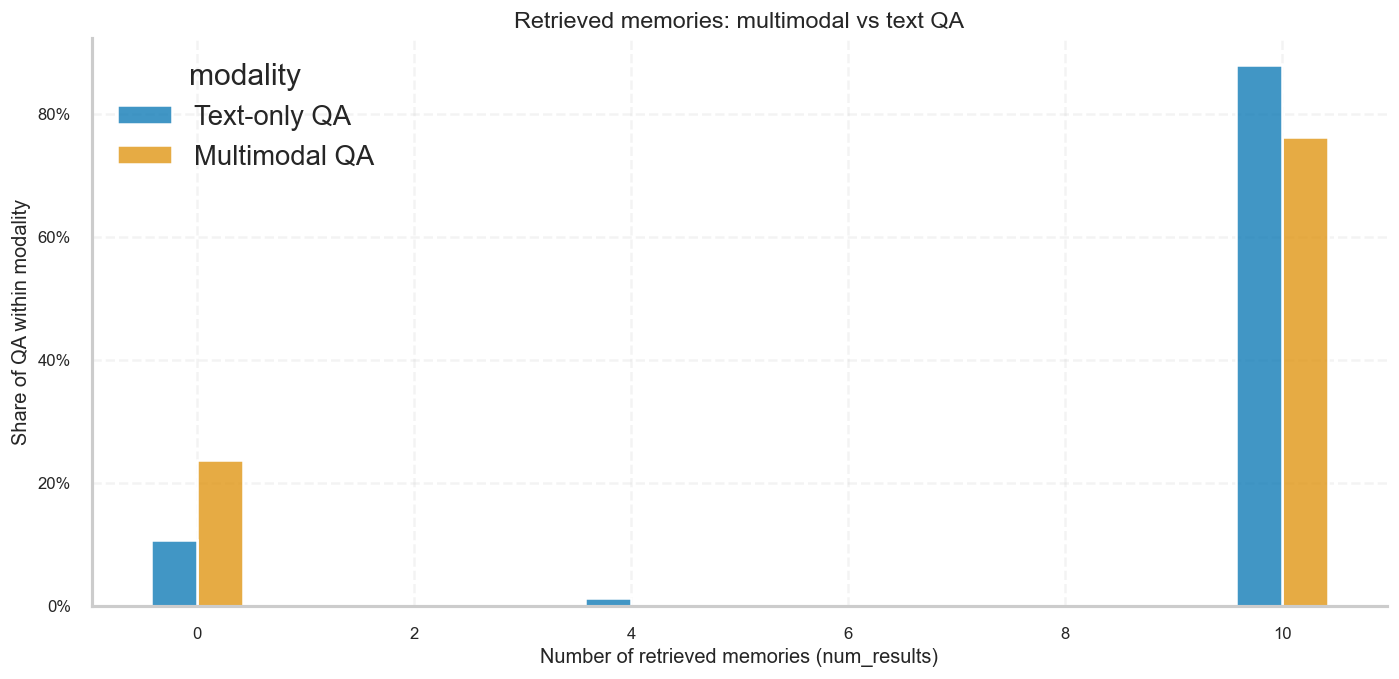

In [26]:
# Retrieved memories comparison (Multimodal vs Text-only) - added at end
retrieval_plot_df = s2.copy()
retrieval_plot_df["num_results_int"] = pd.to_numeric(
    retrieval_plot_df["num_results"], errors="coerce"
).fillna(0).astype(int)

plt.figure(figsize=(12, 6))
sns.histplot(
    data=retrieval_plot_df,
    x="num_results_int",
    hue="modality",
    multiple="dodge",
    stat="probability",
    common_norm=False,
    discrete=True,
    shrink=0.85,
)
plt.title("Retrieved memories: multimodal vs text QA")
plt.xlabel("Number of retrieved memories (num_results)")
plt.ylabel("Share of QA within modality")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

## Retrieved Memories: Text Summary

From the latest Stage 2 QA log (`stage2_RUN-3_qa_20260312_112818.json`):

- **Multimodal QA** (`n=2,487`): mean `num_results` = **7.63**, median = **10**, 75th percentile = **10**, zero-retrieval share = **23.7%**
- **Text-only QA** (`n=2,513`): mean `num_results` = **8.85**, median = **10**, 75th percentile = **10**, zero-retrieval share = **10.7%**

**Difference:** text-only QA retrieves about **1.22** more memories on average, and has a much lower zero-retrieval rate (**10.7% vs 23.7%**).

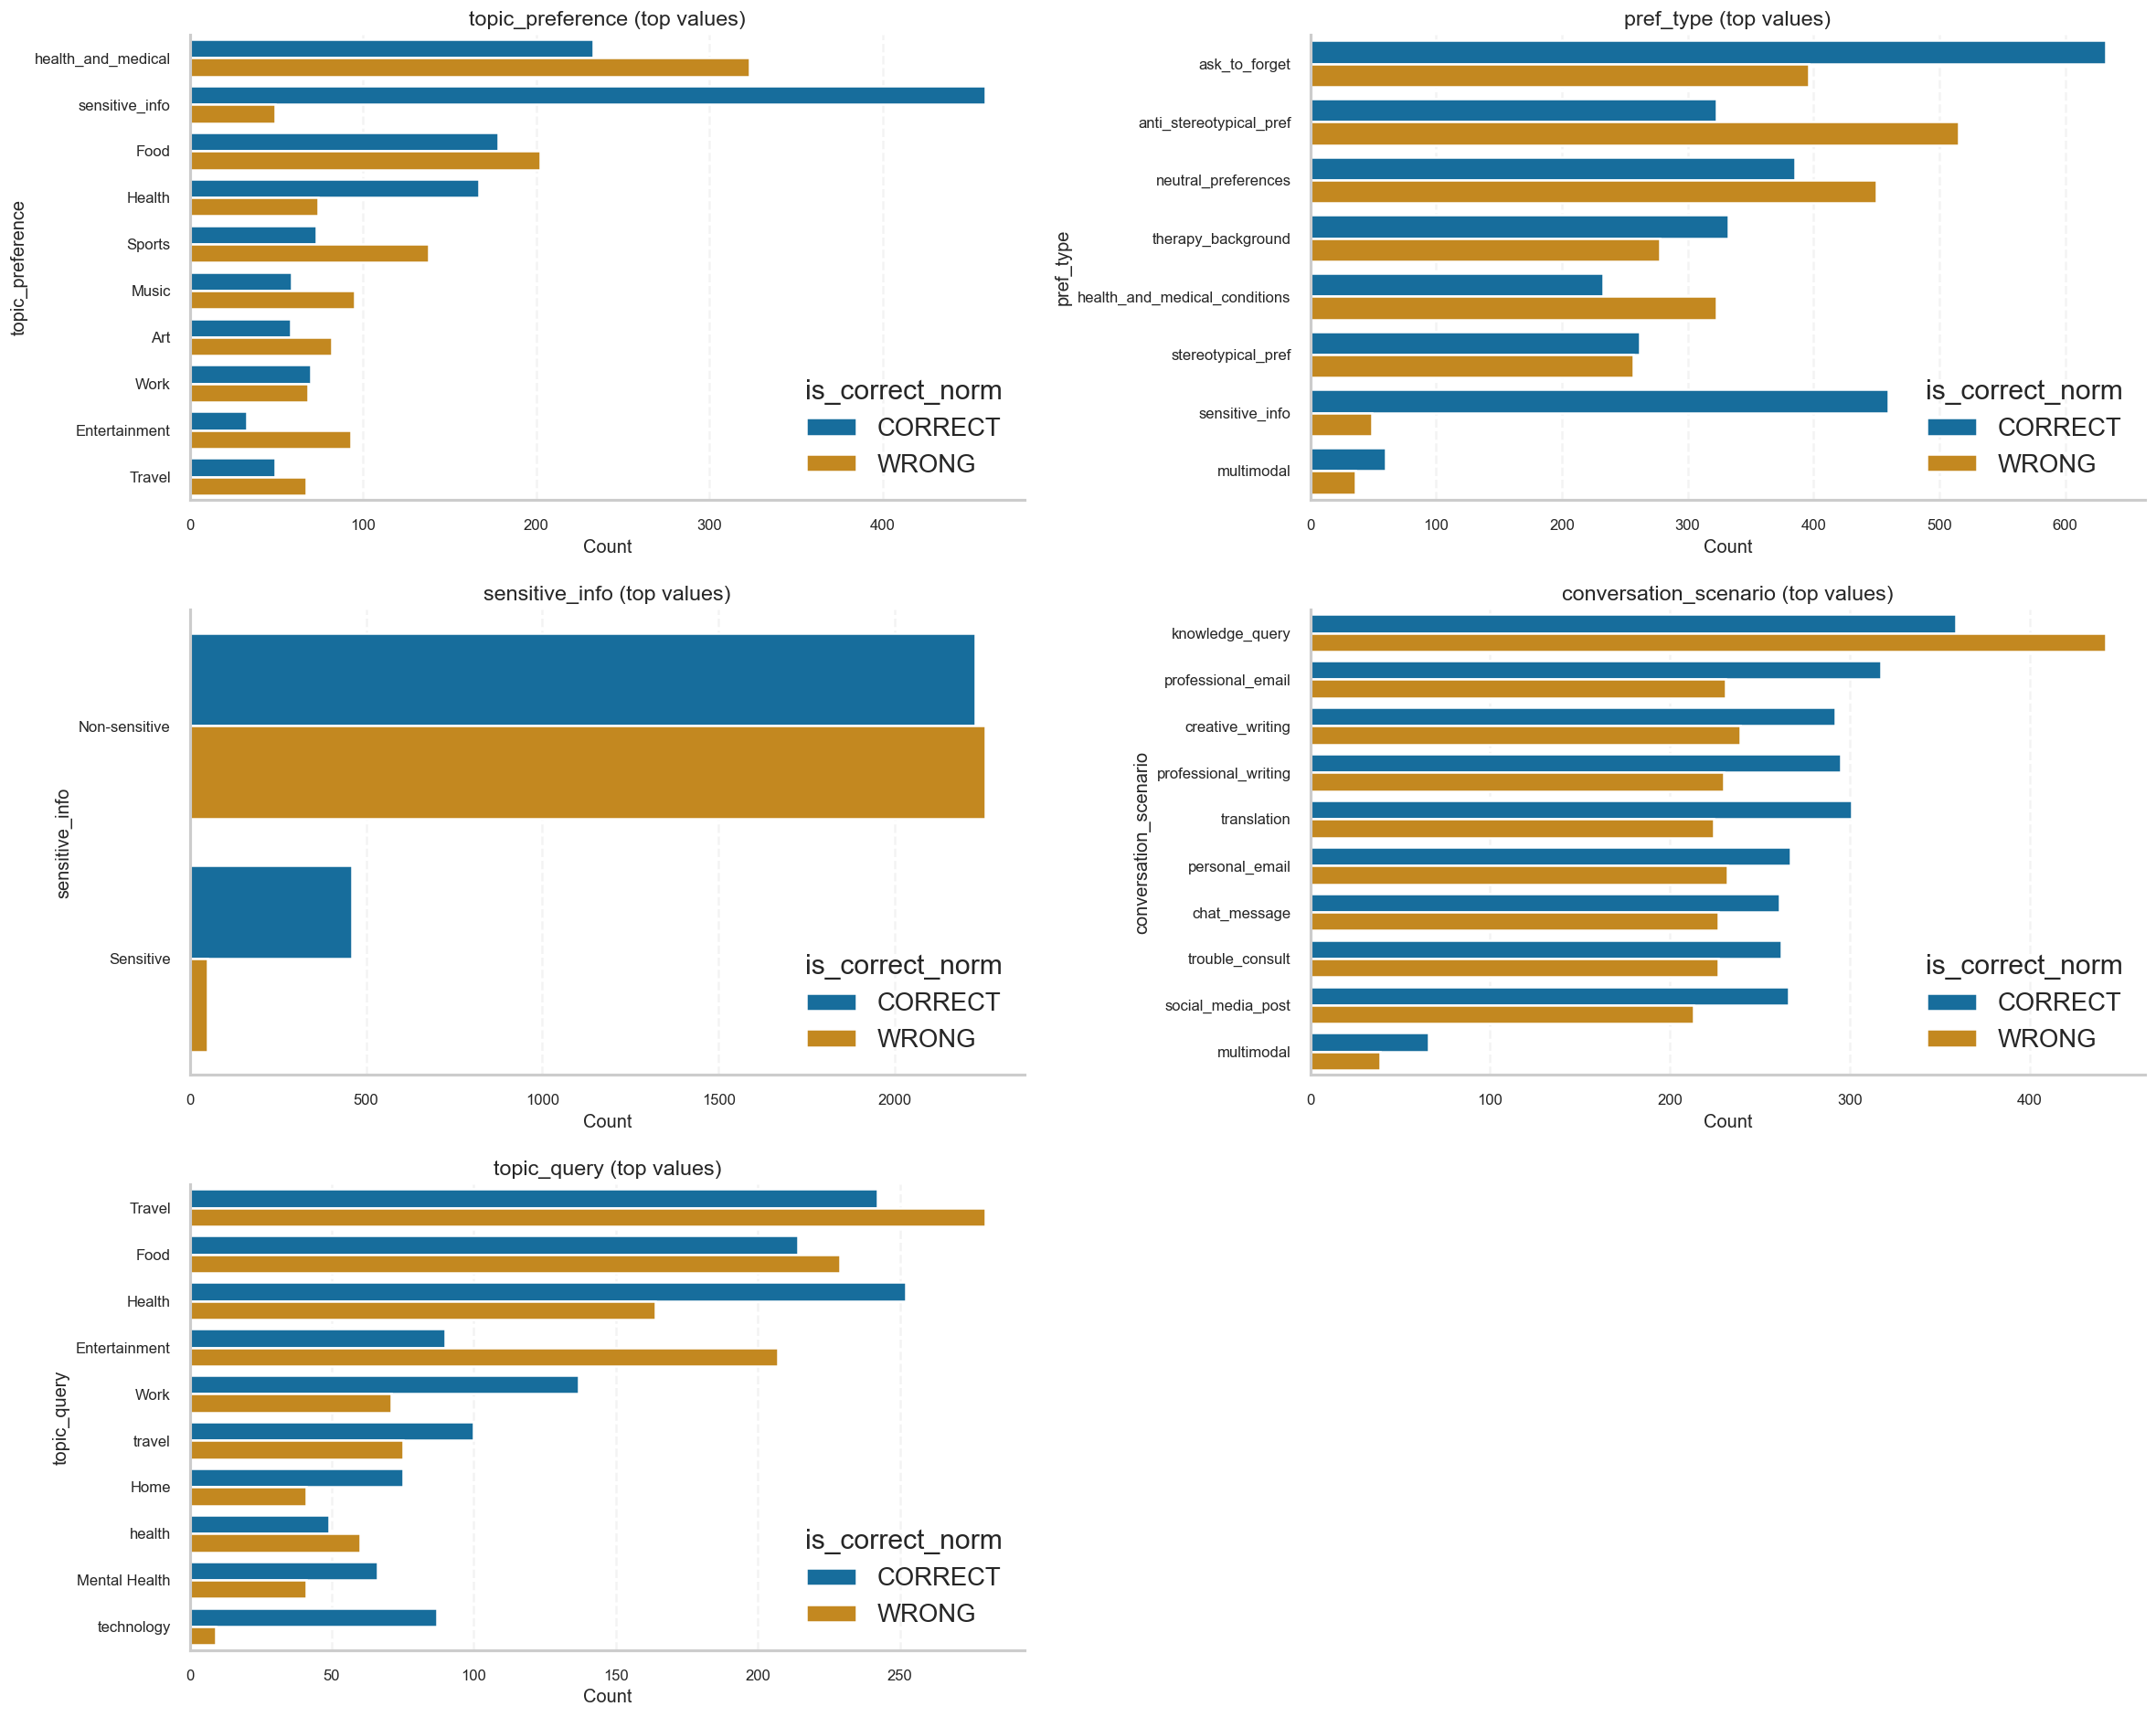

In [27]:
# Checked-results categorical plots for preference/scenario/topic fields
plot_fields = [
    "topic_preference",
    "pref_type",
    "sensitive_info",
    "conversation_scenario",
    "topic_query",
]

checked_plot_df = None

if "judge_df" in locals() and judge_df is not None and not judge_df.empty:
    checked_plot_df = judge_df.copy()
elif CHECKED_RESULTS_PATH and Path(CHECKED_RESULTS_PATH).is_file():
    with open(CHECKED_RESULTS_PATH, "r") as f:
        checked_raw = json.load(f)

    if isinstance(checked_raw, dict) and isinstance(checked_raw.get("per_qa"), list):
        checked_plot_df = pd.DataFrame(checked_raw["per_qa"])
    elif isinstance(checked_raw, dict) and isinstance(checked_raw.get("results"), list):
        checked_plot_df = pd.DataFrame(checked_raw["results"])
    elif isinstance(checked_raw, list):
        checked_plot_df = pd.DataFrame(checked_raw)

if checked_plot_df is None or checked_plot_df.empty:
    print("No checked-results rows available for plotting.")
else:
    # Optional correctness hue if present.
    if "is_correct" in checked_plot_df.columns:
        checked_plot_df["is_correct_norm"] = checked_plot_df["is_correct"].astype(str).str.upper().str.strip()
    elif "label" in checked_plot_df.columns:
        checked_plot_df["is_correct_norm"] = checked_plot_df["label"].astype(str).str.upper().str.strip()
    else:
        checked_plot_df["is_correct_norm"] = "UNKNOWN"

    checked_plot_df["sensitive_info"] = checked_plot_df.get("sensitive_info", False).fillna(False).astype(bool).map({True: "Sensitive", False: "Non-sensitive"})

    fig, axes = plt.subplots(3, 2, figsize=(20, 16))
    axes = axes.flatten()

    for idx, field in enumerate(plot_fields):
        ax = axes[idx]
        if field not in checked_plot_df.columns:
            ax.set_title(f"{field}: not available")
            ax.axis("off")
            continue

        top_vals = checked_plot_df[field].fillna("Unknown").astype(str).value_counts().head(10).index
        plot_df = checked_plot_df[checked_plot_df[field].fillna("Unknown").astype(str).isin(top_vals)].copy()
        plot_df[field] = plot_df[field].fillna("Unknown").astype(str)

        counts = (
            plot_df.groupby([field, "is_correct_norm"], dropna=False)
                   .size()
                   .reset_index(name="count")
        )

        sns.barplot(
            data=counts,
            y=field,
            x="count",
            hue="is_correct_norm",
            order=list(top_vals),
            ax=ax,
        )
        ax.set_title(f"{field} (top values)")
        ax.set_xlabel("Count")
        ax.set_ylabel(field)

    # Remove the unused 6th subplot slot.
    axes[-1].axis("off")

    plt.tight_layout()
    plt.show()

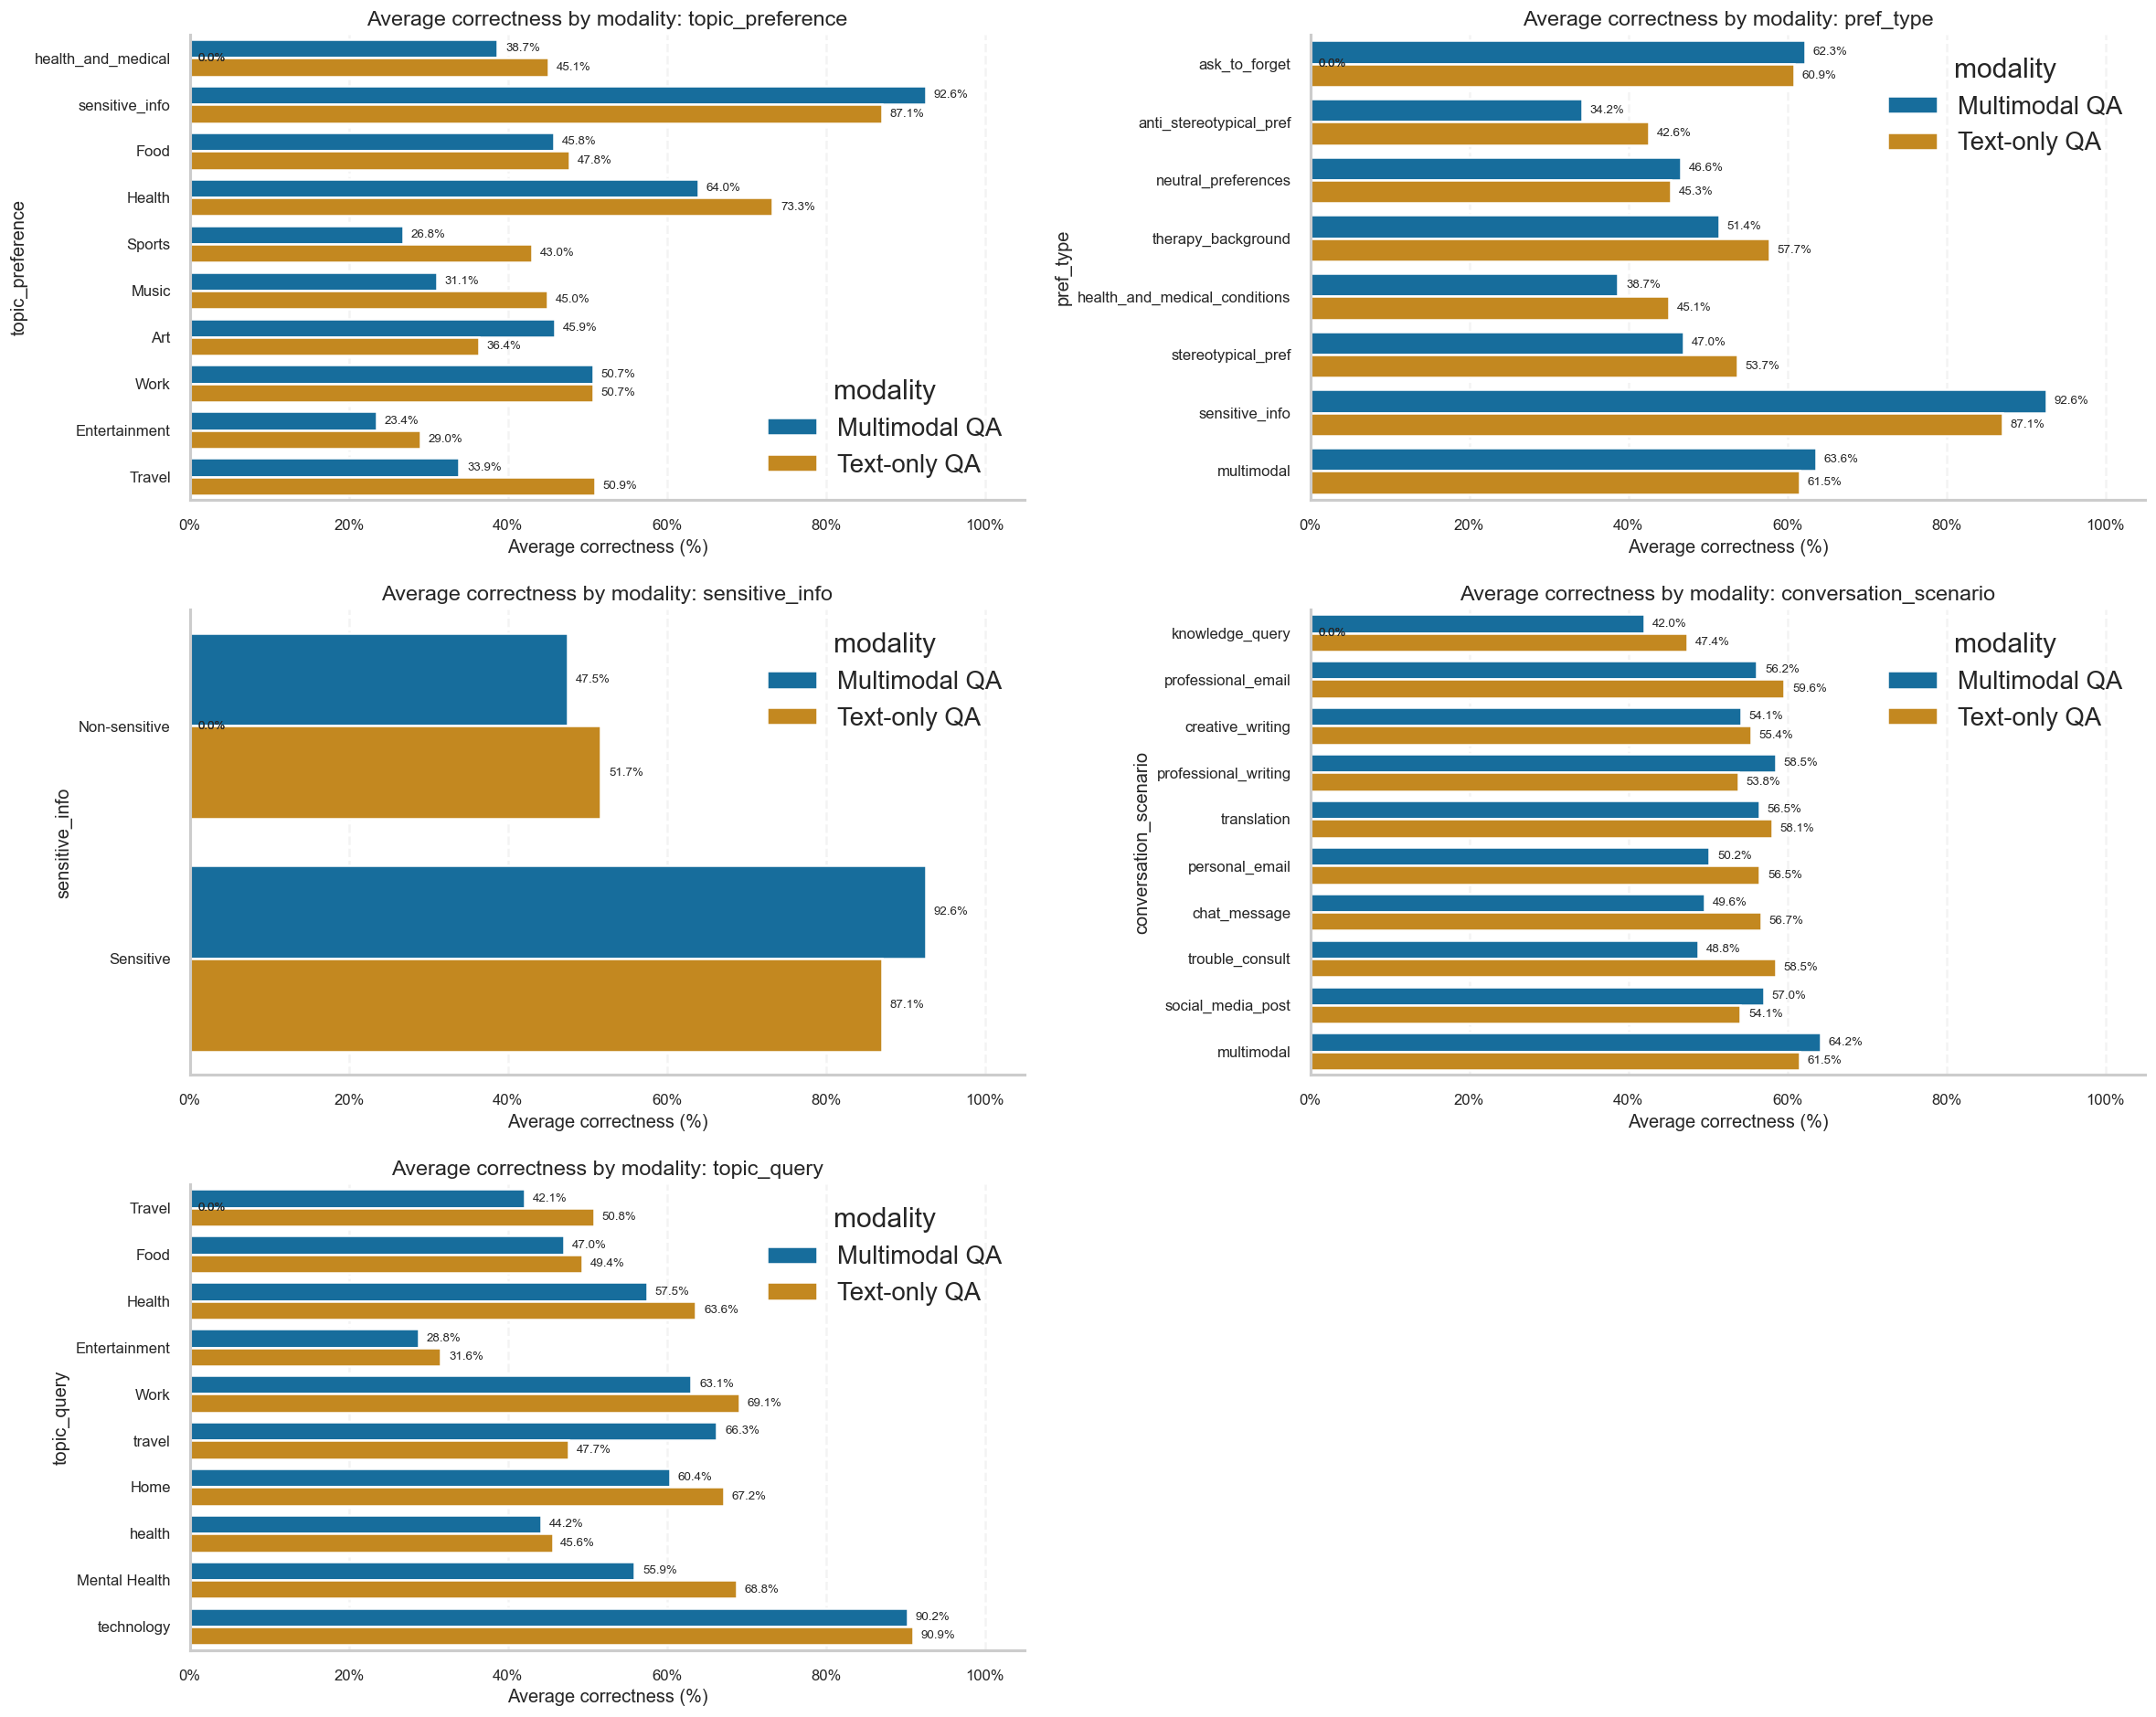

,topic_preference,modality,avg_correct,total,field_name,pref_type,sensitive_info,conversation_scenario,topic_query,avg_correct_pct
44,NaN,Multimodal QA,0.419903,412,conversation_scenario,NaN,NaN,knowledge_query,NaN,41.99
45,NaN,Text-only QA,0.474490,392,conversation_scenario,NaN,NaN,knowledge_query,NaN,47.45
50,NaN,Multimodal QA,0.561837,283,conversation_scenario,NaN,NaN,professional_email,NaN,56.18
57,NaN,Text-only QA,0.580645,279,conversation_scenario,NaN,NaN,translation,NaN,58.06
53,NaN,Text-only QA,0.538462,273,conversation_scenario,NaN,NaN,professional_writing,NaN,53.85
...,...,...,...,...,...,...,...,...,...,...
77,NaN,Text-only QA,0.909091,55,topic_query,NaN,NaN,NaN,technology,90.91
66,NaN,Multimodal QA,0.603774,53,topic_query,NaN,NaN,NaN,Home,60.38
74,NaN,Multimodal QA,0.442308,52,topic_query,NaN,NaN,NaN,health,44.23
69,NaN,Text-only QA,0.687500,48,topic_query,NaN,NaN,NaN,Mental Health,68.75


In [28]:
# Average correctness by modality (Text-only vs Multimodal) across checked-results fields
avg_fields = [
    "topic_preference",
    "pref_type",
    "sensitive_info",
    "conversation_scenario",
    "topic_query",
]

avg_df = None

if "judge_df" in locals() and judge_df is not None and not judge_df.empty:
    avg_df = judge_df.copy()
elif CHECKED_RESULTS_PATH and Path(CHECKED_RESULTS_PATH).is_file():
    with open(CHECKED_RESULTS_PATH, "r") as f:
        checked_raw = json.load(f)

    if isinstance(checked_raw, dict) and isinstance(checked_raw.get("per_qa"), list):
        avg_df = pd.DataFrame(checked_raw["per_qa"])
    elif isinstance(checked_raw, dict) and isinstance(checked_raw.get("results"), list):
        avg_df = pd.DataFrame(checked_raw["results"])
    elif isinstance(checked_raw, list):
        avg_df = pd.DataFrame(checked_raw)

if avg_df is None or avg_df.empty:
    print("No checked-results rows available for average-by-modality plots.")
else:
    # Ensure question_id for modality join.
    if "question_id" not in avg_df.columns and {"user_id", "row_index"}.issubset(avg_df.columns):
        avg_df["question_id"] = avg_df["user_id"].astype(str) + ":" + avg_df["row_index"].astype(str)

    if "question_id" in avg_df.columns and {"question_id", "modality"}.issubset(s2.columns):
        avg_df = avg_df.merge(s2[["question_id", "modality"]].drop_duplicates(), on="question_id", how="left")

    avg_df["modality"] = avg_df.get("modality", "Unknown").fillna("Unknown")

    # Use readable labels instead of raw booleans.
    if "sensitive_info" in avg_df.columns:
        avg_df["sensitive_info"] = avg_df["sensitive_info"].map({True: "Sensitive", False: "Non-sensitive"}).fillna("Unknown")

    # Build correctness metric for averaging.
    if "is_correct" in avg_df.columns:
        avg_df["is_correct_norm"] = avg_df["is_correct"].astype(str).str.upper().str.strip()
    elif "label" in avg_df.columns:
        avg_df["is_correct_norm"] = avg_df["label"].astype(str).str.upper().str.strip()
    else:
        avg_df["is_correct_norm"] = "UNKNOWN"

    avg_df["correct"] = (avg_df["is_correct_norm"] == "CORRECT").astype(int)

    fig, axes = plt.subplots(3, 2, figsize=(20, 16))
    axes = axes.flatten()

    field_summaries = []

    for idx, field in enumerate(avg_fields):
        ax = axes[idx]

        if field not in avg_df.columns:
            ax.set_title(f"{field}: not available")
            ax.axis("off")
            continue

        plot_df = avg_df[[field, "modality", "correct"]].copy()
        plot_df[field] = plot_df[field].fillna("Unknown").astype(str)

        top_vals = plot_df[field].value_counts().head(10).index
        plot_df = plot_df[plot_df[field].isin(top_vals)]

        agg = (
            plot_df.groupby([field, "modality"], dropna=False)
                   .agg(avg_correct=("correct", "mean"), total=("correct", "size"))
                   .reset_index()
        )
        field_summaries.append(agg.assign(field_name=field))

        sns.barplot(
            data=agg,
            y=field,
            x="avg_correct",
            hue="modality",
            order=list(top_vals),
            ax=ax,
        )
        ax.set_xlim(0, 1.05)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        ax.set_title(f"Average correctness by modality: {field}")
        ax.set_xlabel("Average correctness (%)")
        ax.set_ylabel(field)

        # Label bars directly as percentages.
        for patch in ax.patches:
            w = patch.get_width()
            if pd.notna(w):
                ax.text(
                    min(1.03, w + 0.01),
                    patch.get_y() + patch.get_height() / 2,
                    f"{w:.1%}",
                    va="center",
                    ha="left",
                    fontsize=8,
                )

    axes[-1].axis("off")

    plt.tight_layout()
    plt.show()

    if field_summaries:
        summary_df = pd.concat(field_summaries, ignore_index=True).sort_values(["field_name", "total"], ascending=[True, False])
        summary_df["avg_correct_pct"] = (100 * summary_df["avg_correct"]).round(2)
        display(summary_df)